# Showcase how to get an SSP template using pyFSPS

This notebook will show you how you get an SSP template using the python binding (*pyFSPS*) to Charly Conroy's *FSPS* package.
For more information about *pyFSPS* see https://dfm.io/python-fsps/current/ for more information about *FSPS* see https://github.com/cconroy20/fsps

NOTE: In order to make this notebook work please first install *pyFSPS* following the installation guide here: https://dfm.io/python-fsps/current/installation/

In particular, you will need to set the `SPS_HOME` environment variable.

Since switching between different supported stellar isochrone and spectral libraries in *pyFSPS* requires (re-) installing *pyFSPS* with specific compiler flags **we do not add a dependence onto *pyFSPS*** and leave the installation of it to the user. See here https://dfm.io/python-fsps/current/installation/ for information on the install process.

Currently Rubix supports to run *pyFSPS* to create an SSP template from scratch -- use the config option `source=rerun_from_scratch`. But note, this is mainly a wrapper around the *pyFSPS* `StellarPopulation()` and `get_spectrum()` functions. If you use the `get_ssp_template()` function from *Rubix* to create the ssp template via *pyFSPS* it will only pass default parameters (`add_neb_emission=True, imf_type=2, zmet=None, tage=0.0, peraa=True`) over to pyFSPS.

While its possible to pass all relevant function parameters to *pyFSPS* through `rubix.spectra.ssp.fsps_grid.retrieve_ssp_data_from_fsps()` or `.write_fsps_data_to_disk()` we recommend to run *pyFSPS* separate from *Rubix* if you want full control over the process.

Since *pyFSPS* runs can take quite some time, this will silently save the ssp template to a *hdf5* file with filename specified under the config entry `filename`. Additionally we support to load pre-existing templates created via *FSPS* using the config option `source=load_from_file` via our standard `HDF5SSPGrid` class.

In [2]:
# NBVAL_SKIP
from rubix.spectra.ssp.factory import get_ssp_template
ssp = get_ssp_template("FSPS")
ssp

2025-11-10 14:54:53,636 - rubix - INFO - 
   ___  __  _____  _____  __
  / _ \/ / / / _ )/  _/ |/_/
 / , _/ /_/ / _  |/ /_>  <
/_/|_|\____/____/___/_/|_|


2025-11-10 14:54:53,637 - rubix - INFO - Rubix version: 0.0.post503+g060c53b49.d20251002
2025-11-10 14:54:53,637 - rubix - INFO - JAX version: 0.4.38
2025-11-10 14:54:53,653 - rubix - INFO - Running on [CpuDevice(id=0)] devices


HDF5SSPGrid(age=Array([9.9999997e-05, 1.1220184e-04, 1.2589252e-04, 1.4125378e-04,
       1.5848933e-04, 1.7782794e-04, 1.9952621e-04, 2.2387206e-04,
       2.5118870e-04, 2.8183832e-04, 3.1622776e-04, 3.5481335e-04,
       3.9810708e-04, 4.4668370e-04, 5.0118729e-04, 5.6234130e-04,
       6.3095725e-04, 7.0794561e-04, 7.9432840e-04, 8.9125102e-04,
       1.0000000e-03, 1.1220183e-03, 1.2589252e-03, 1.4125379e-03,
       1.5848933e-03, 1.7782794e-03, 1.9952620e-03, 2.2387207e-03,
       2.5118869e-03, 2.8183833e-03, 3.1622776e-03, 3.5481334e-03,
       3.9810711e-03, 4.4668368e-03, 5.0118729e-03, 5.6234132e-03,
       6.3095726e-03, 7.0794565e-03, 7.9432838e-03, 8.9125102e-03,
       9.9999998e-03, 1.1220183e-02, 1.2589254e-02, 1.4125375e-02,
       1.5848933e-02, 1.7782794e-02, 1.9952621e-02, 2.2387212e-02,
       2.5118863e-02, 2.8183833e-02, 3.1622775e-02, 3.5481334e-02,
       3.9810721e-02, 4.4668358e-02, 5.0118729e-02, 5.6234132e-02,
       6.3095726e-02, 7.0794582e-02, 7.9432823

In [3]:
config = {
      "name": "FSPS (Conroy et al. 2009)",
      # more information on how those models are synthesized: https://github.com/cconroy20/fsps
      # and https://dfm.io/python-fsps/current/
      "format": "fsps", # Format of the template
      "source": "load_from_file", # the source can be "load_from_file" or "rerun_from_scratch"
      # "load_from_file" is the default and loads the template from a pre-existing file in h5 format specified by "file_name"
      # if that file is not found, it will automatically run fsps and save the output to disk in h5 format under the "file_name" given.
      # "rerun_from_scratch" # note: this is just meant for the case in which you really want to rerun your template library.
      # You should be aware that fsps templates will silently be overwritten by this. Use with caution.
      "file_name": "fsps.h5", # File name of the template, stored in templates directory
      # Define the Fields in the template and their units
      # This is used to convert them to the required units
      "fields":{ # Fields in the template and their units
        # Name defines the name of the key stored in the hdf5 file
        "age":{
          "name": "age",
          "units": "Gyr", # Age of the template
          "in_log": True # If the field is stored in log scale
          },
        "metallicity":{
          "name": "metallicity",
          "units": "", # Metallicity of the template
          "in_log": True # If the field is stored in log scale
          },
        "wavelength":{
          "name": "wavelength",
          "units": "Angstrom", # Wavelength of the template
          "in_log": False # If the field is stored in log scale
          },
        "flux":{
          "name": "flux",
          "units": "Lsun/Angstrom", # Luminosity of the template as per pyFSPS documentation
          "in_log": False # If the field is stored in log scale
          }
        }
}

In [4]:
# NBVAL_SKIP
ssp.age.shape

(107,)

In [5]:
# NBVAL_SKIP
ssp.metallicity.shape

(12,)

In [6]:
# NBVAL_SKIP
ssp.wavelength.shape

(5994,)

In [7]:
# NBVAL_SKIP
ssp.flux.shape

(12, 107, 5994)

In [8]:
# NBVAL_SKIP
import os
from rubix.paths import TEMPLATE_PATH
os.path.exists(os.path.join(TEMPLATE_PATH, config['file_name']))

True

## Let's plot some of the spectra

In [9]:
# NBVAL_SKIP
import matplotlib.pyplot as plt
import numpy as np

(0.0, 10000.0)

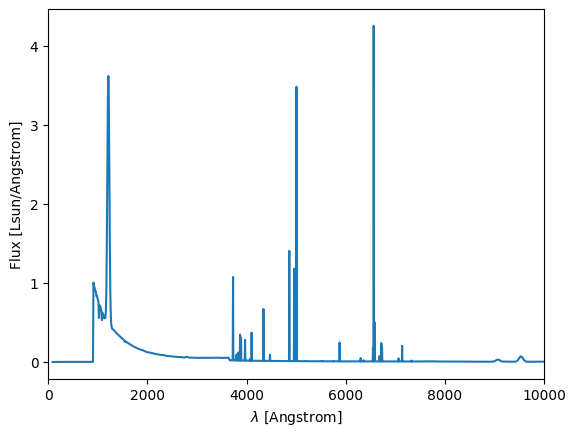

In [10]:
# NBVAL_SKIP
plt.plot(ssp.wavelength,ssp.flux[0][0])
plt.xlabel(r'$\lambda$ [%s]'%config["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config["fields"]["flux"]["units"])
#plt.yscale("log")
plt.xlim(0,10000)

(0.0, 10000.0)

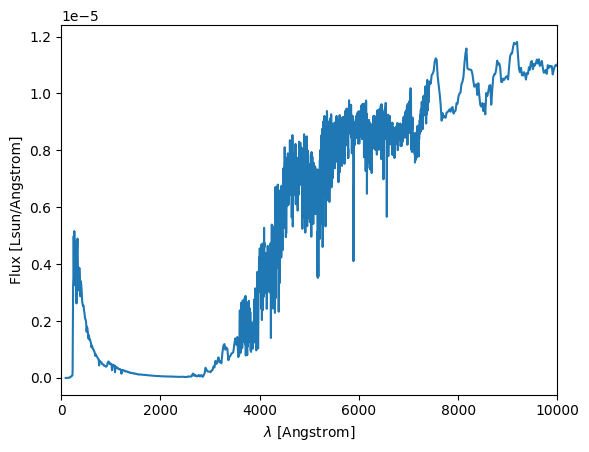

In [11]:
# NBVAL_SKIP
plt.plot(ssp.wavelength,ssp.flux[-1][-1])
plt.xlabel(r'$\lambda$ [%s]'%config["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config["fields"]["flux"]["units"])
#plt.yscale("log")
plt.xlim(0,10000)

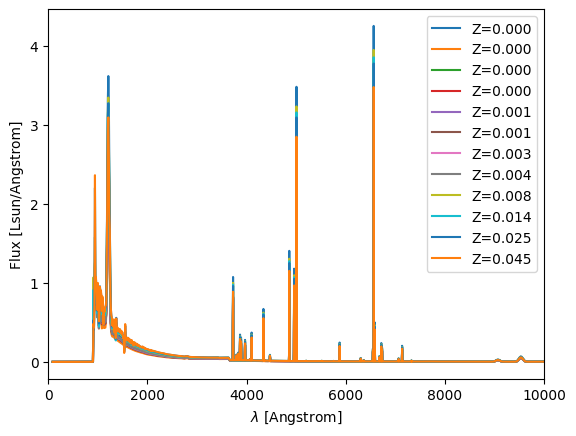

In [12]:
# NBVAL_SKIP
for i in range(len(ssp.metallicity)):
    plt.plot(ssp.wavelength,ssp.flux[i][0], label=r'Z=%0.3f'%ssp.metallicity[i])
plt.xlabel(r'$\lambda$ [%s]'%config["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config["fields"]["flux"]["units"])
#plt.yscale("log")
plt.xlim(0,10000)
plt.legend()

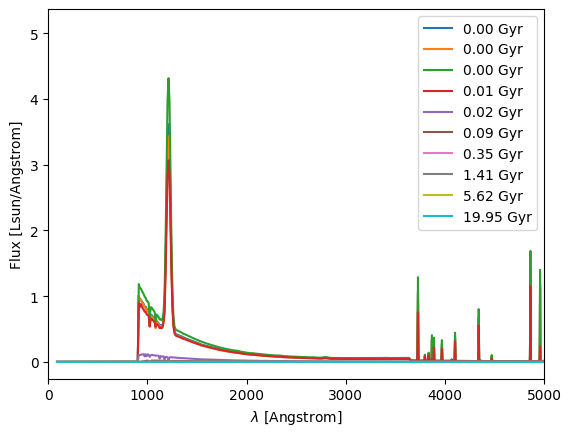

In [13]:
# NBVAL_SKIP
ages = np.linspace(0,len(ssp.age),10)
for age in ages:
    plt.plot(ssp.wavelength,ssp.flux[0][int(age)], label='%.2f %s'%(ssp.age[int(age)], config["fields"]["age"]["units"]))
plt.xlabel(r'$\lambda$ [%s]'%config["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config["fields"]["flux"]["units"])
#plt.yscale("log")
plt.xlim(0,5000)
plt.legend()

## Reload the created FSPS template

This is only for tutorial purposes as you would need to run fsps like above first to have a pre-existing template...

In [14]:
#NBVAL_SKIP
from rubix import config as rubix_config
rubix_config["ssp"]["templates"]["FSPS"]["source"] = "load_from_file"

In [15]:
# NBVAL_SKIP
ssp2 = get_ssp_template("FSPS")
ssp2

HDF5SSPGrid(age=Array([9.9999997e-05, 1.1220184e-04, 1.2589252e-04, 1.4125378e-04,
       1.5848933e-04, 1.7782794e-04, 1.9952621e-04, 2.2387206e-04,
       2.5118870e-04, 2.8183832e-04, 3.1622776e-04, 3.5481335e-04,
       3.9810708e-04, 4.4668370e-04, 5.0118729e-04, 5.6234130e-04,
       6.3095725e-04, 7.0794561e-04, 7.9432840e-04, 8.9125102e-04,
       1.0000000e-03, 1.1220183e-03, 1.2589252e-03, 1.4125379e-03,
       1.5848933e-03, 1.7782794e-03, 1.9952620e-03, 2.2387207e-03,
       2.5118869e-03, 2.8183833e-03, 3.1622776e-03, 3.5481334e-03,
       3.9810711e-03, 4.4668368e-03, 5.0118729e-03, 5.6234132e-03,
       6.3095726e-03, 7.0794565e-03, 7.9432838e-03, 8.9125102e-03,
       9.9999998e-03, 1.1220183e-02, 1.2589254e-02, 1.4125375e-02,
       1.5848933e-02, 1.7782794e-02, 1.9952621e-02, 2.2387212e-02,
       2.5118863e-02, 2.8183833e-02, 3.1622775e-02, 3.5481334e-02,
       3.9810721e-02, 4.4668358e-02, 5.0118729e-02, 5.6234132e-02,
       6.3095726e-02, 7.0794582e-02, 7.9432823

In [16]:
# NBVAL_SKIP
ssp.wavelength.shape == ssp2.wavelength.shape

True